# CCE Moorings - Data Visualization  

**Purpose**: Code for visualizing the Potential Density, along-shelf velocity, and cross-shelf velocities and mooring positions. 

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook: 

In [1]:
%matplotlib inline

Import python libraries

In [2]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import cmocean
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.lines as mlines
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import geopandas as gpd

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
import cartopy_figs as cart
from lsf import unweighted_lsf, detrend
from plotScaleAnalysis import add_corner_label, month_fmt

Set data analysis parameters

In [3]:
# Set time and space parameters
lat_bnds   = [33, 35]                      # Specifies the latitude bounds for the region to analyze
lon_bnds   = [-123 % 360, -120 % 360]      # Specifies the longitude bounds for the region to analyze

#--- CCE1 ---# 
st_cce1_ctd      = datetime(2016, 1, 1, 0, 0, 0)       # Specifies the start time of the event period 
ed_cce1_ctd      = datetime(2017, 12, 31, 23, 59, 59)  # Specifies the end time of the event period       

st_cce1_adcp      = datetime(2014, 1, 1, 0, 0, 0)       # Specifies the start time of the event period 
ed_cce1_adcp      = datetime(2015, 12, 31, 23, 59, 59)  # Specifies the end time of the event period       

#--- CCE2 ---# 
st_cce2_ctd      = datetime(2020, 1, 1, 0, 0, 0)       # Specifies the start time of the event period 
ed_cce2_ctd      = datetime(2021, 12, 31, 23, 59, 59)  # Specifies the end time of the event period       

st_cce2_adcp      = datetime(2014, 1, 1, 0, 0, 0)       # Specifies the start time of the event period 
ed_cce2_adcp      = datetime(2015, 12, 31, 23, 59, 59)  # Specifies the end time of the event period       

# Set path to project directory
PATH = "/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/AirSeaCoupling"
PATH_bathy  = ROOT + 'AirSeaCoupling/data/bathymetry/'
PATH_calCOFI = ROOT + 'AirSeaCoupling/data/calCOFI/'
PATH_figs   = ROOT + 'AirSeaCoupling/figs/paper_figures/'

# Set plotting parameters 
fontsize = 18

# Set font 
os.environ["PATH"] = "/usr/local/texlive/2022/bin/universal-darwin:" + os.environ["PATH"]
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
})

#----------------------------------#
# Note - Time Periods for ADCP/CTD Processing
#----------------------------------#
#
# CTD Processing
# --------------
#   CCE1 - datetime(2016, 1, 1, 0, 0, 0) to datetime(2017, 12, 31, 23, 59, 59) 
#   CCE2 - datetime(2020, 1, 1, 0, 0, 0) to datetime(2021, 12, 31, 23, 59, 59) 
#  
# ADCP Processing
# --------------
#   CCE1 - datetime(2014, 1, 1, 0, 0, 0) to datetime(2015, 12, 31, 23, 59, 59) at -2000 m isobath
#   CCE2 - datetime(2014, 1, 1, 0, 0, 0) to datetime(2015, 12, 31, 23, 59, 59) at -2000 m isobath
# 
# Note that these is a difference in the time periods for the gridded and non-gridded products for CCE2 CTD processing. 
# This is because the publically available CTD data on the thredds server does not have an OS_CCE2_13_D_CTD.nc file 
# which spans from 2021/06 to 2022/07. So I can not process data from 2020 through 2021. The gridded data does extend
# all the way through 2021 and the 2020 to 2021 years have the most continuous and most depth levels in the time series.

Load CCE processed data

In [4]:
# Set the file name and read in the data file
filename_CCE1_ctd  = PATH + "/data/CCE/CCE1/CTD/CCE1_CTD_" + str(st_cce1_ctd.year) + str(st_cce1_ctd.month) + str(st_cce1_ctd.day) +  "-" + str(ed_cce1_ctd.year) + str(ed_cce1_ctd.month) + str(ed_cce1_ctd.day) + "_intermediate_gridded_data.nc"
filename_CCE1_adcp = PATH + "/data/CCE/CCE1/ADCP/CCE1_ADCP_" + str(st_cce1_adcp.year) + str(st_cce1_adcp.month) + str(st_cce1_adcp.day) +  "-" + str(ed_cce1_adcp.year) + str(ed_cce1_adcp.month) + str(ed_cce1_adcp.day) + "_intermediate_data.nc"

filename_CCE2_ctd  = PATH + "/data/CCE/CCE2/CTD/CCE2_CTD_" + str(st_cce2_ctd.year) + str(st_cce2_ctd.month) + str(st_cce2_ctd.day) +  "-" + str(ed_cce2_ctd.year) + str(ed_cce2_ctd.month) + str(ed_cce2_ctd.day) + "_intermediate_gridded_data.nc"
filename_CCE2_adcp = PATH + "/data/CCE/CCE2/ADCP/CCE2_ADCP_" + str(st_cce2_adcp.year) + str(st_cce2_adcp.month) + str(st_cce2_adcp.day) +  "-" + str(ed_cce2_adcp.year) + str(ed_cce2_adcp.month) + str(ed_cce2_adcp.day) + "_intermediate_data.nc"

#--- CCE 1 ---# 
nc_CCE1_ctd  = Dataset(filename_CCE1_ctd, 'r')
nc_CCE1_adcp = Dataset(filename_CCE1_adcp, 'r')

# Extract data variables
depth1           = nc_CCE1_ctd.variables['depth'][:]
time1            = num2date(nc_CCE1_ctd.variables['time'][:], nc_CCE1_ctd.variables['time'].units)
lon1             = nc_CCE1_ctd.variables['LON'][:]
lat1             = nc_CCE1_ctd.variables['LAT'][:]

RHO1             = nc_CCE1_ctd.variables['SIG0'][:]
SA1              = nc_CCE1_ctd.variables['ASal'][:]
CT1              = nc_CCE1_ctd.variables['CTemp'][:]

depth1_adcp      = nc_CCE1_adcp.variables['depth'][:]
time1_adcp       = num2date(nc_CCE1_adcp.variables['time'][:], nc_CCE1_adcp.variables['time'].units)

U1               = nc_CCE1_adcp.variables['U_shelf'][:]
V1               = nc_CCE1_adcp.variables['V_shelf'][:]
U1_depth         = nc_CCE1_adcp.variables['U_shelf_depth'][:]
V1_depth         = nc_CCE1_adcp.variables['V_shelf_depth'][:]

# Convert cftime.DatetimeGregorian to Python datetime objects
time1_dt      = np.array([datetime(d.year, d.month, d.day, d.hour, d.minute, d.second) for d in time1])
time1_adcp_dt = np.array([datetime(d.year, d.month, d.day, d.hour, d.minute, d.second) for d in time1_adcp])

#--- CCE 2 ---# 
nc_CCE2_ctd  = Dataset(filename_CCE2_ctd, 'r')
nc_CCE2_adcp = Dataset(filename_CCE2_adcp, 'r')

# Extract data variables
depth2           = nc_CCE2_ctd.variables['depth'][:]
time2            = num2date(nc_CCE2_ctd.variables['time'][:], nc_CCE2_ctd.variables['time'].units)
lon2             = nc_CCE2_ctd.variables['LON'][:]
lat2             = nc_CCE2_ctd.variables['LAT'][:]

RHO2             = nc_CCE2_ctd.variables['SIG0'][:]
SA2              = nc_CCE2_ctd.variables['ASal'][:]
CT2              = nc_CCE2_ctd.variables['CTemp'][:]

depth2_adcp      = nc_CCE2_adcp.variables['depth'][:]
time2_adcp       = num2date(nc_CCE2_adcp.variables['time'][:], nc_CCE2_adcp.variables['time'].units)

U2               = nc_CCE2_adcp.variables['U_shelf'][:]
V2               = nc_CCE2_adcp.variables['V_shelf'][:]
U2_depth         = nc_CCE2_adcp.variables['U_shelf_depth'][:]
V2_depth         = nc_CCE2_adcp.variables['V_shelf_depth'][:]

# Convert cftime.DatetimeGregorian to Python datetime objects
time2_dt      = np.array([datetime(d.year, d.month, d.day, d.hour, d.minute, d.second) for d in time2])
time2_adcp_dt = np.array([datetime(d.year, d.month, d.day, d.hour, d.minute, d.second) for d in time2_adcp])

#--- CCE 3 ---# 
lon3 = -120.53825701527784 % 360
lat3 = 34.44825228022894

Read in bathymetry data

In [5]:
# Load bathymetry data 
filename = PATH_bathy + "topo_25.1.nc"
ds_bathy = xr.open_dataset(filename, engine="netcdf4")

# Extract data variables
lon_b = ds_bathy["lon"]  # Longitude
lat_b = ds_bathy["lat"]  # Latitude
bathy = ds_bathy["z"]    # Elevation/Bathymetry

# Convert convesion of longitude (neg from the prime meridian to positive definite wrapping around the earth)
lon_n = lon_b % 360

# Set max and min values 
lon_min = lon_bnds[0]
lon_max = lon_bnds[1]
lat_min = lat_bnds[0]
lat_max = lat_bnds[1]

# Extract data from bathymetry 
lon_grid = lon_n[(lon_n >= lon_min) & (lon_n <= lon_max)]
lat_grid = lat_b[(lat_b >= lat_min) & (lat_b <= lat_max)]
bathy_grid   = bathy[(lat_b >= lat_min) & (lat_b <= lat_max),(lon_n >= lon_min) & (lon_n <= lon_max)]

Read in CalCOFI stations

In [6]:
# Load CalCOFI csv file 
filename = PATH_calCOFI + "CalCOFIStationOrder.csv"
calCOFI_data = np.genfromtxt(
    filename,
    delimiter=",",
    skip_header=1,
    usecols=(1, 3, 7, 11),
    invalid_raise=False
)

# Grab stations on line 80.0
calCOFI_line80 = calCOFI_data[calCOFI_data[:, 0] == 80.0] 

# Parse data into separate arrays
calCOFI_stn   = calCOFI_line80[:, 0]
calCOFI_lat   = calCOFI_line80[:, 1]
calCOFI_lon   = calCOFI_line80[:, 2]
calCOFI_depth = calCOFI_line80[:, 3]

Plot the bathymetry

/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_4160/1470929871.py:162: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


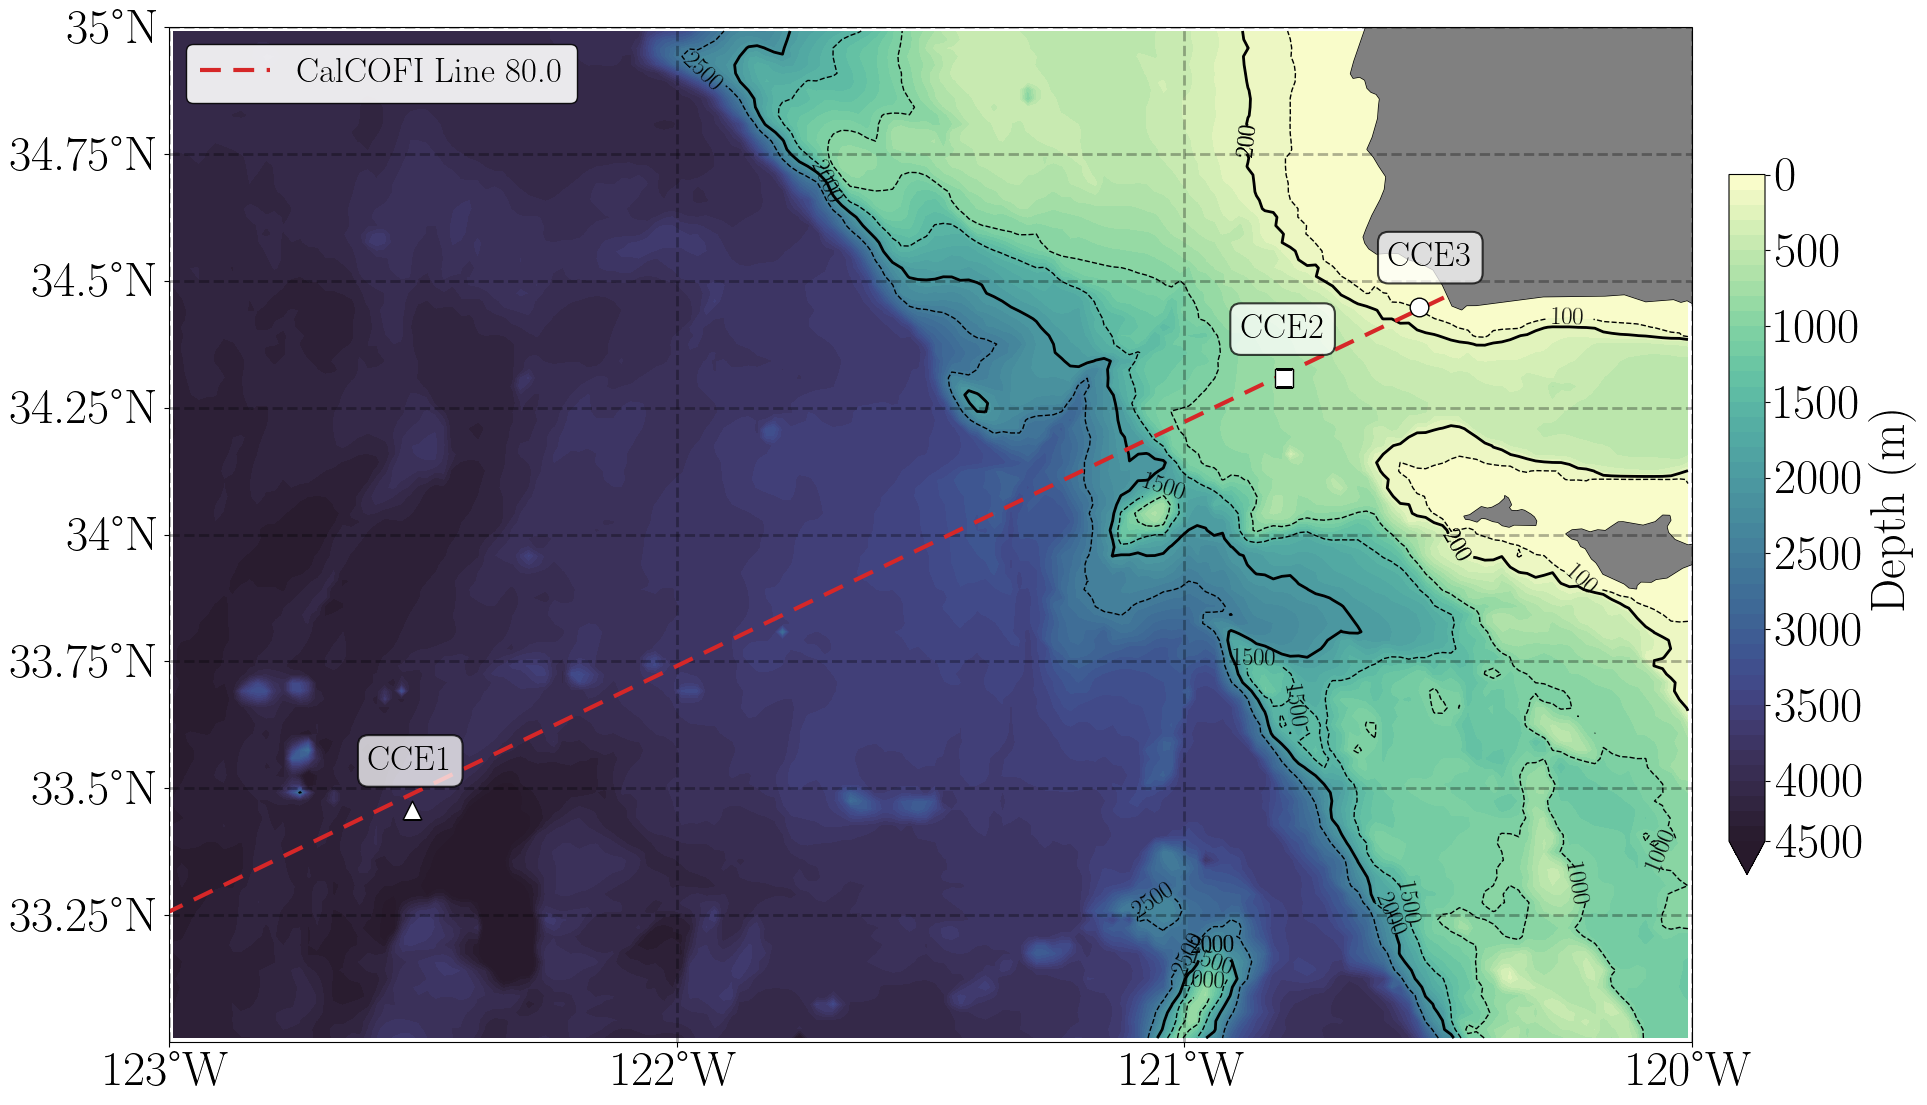

In [9]:
# Set plotting parameters
projection = ccrs.PlateCarree(central_longitude=0.0)
xticks = [-123, -122, -121, -120]
yticks = [33.25, 33.50, 33.75, 34.00, 34.25, 34.50, 34.75, 35.00]
resolution = "10m"
bounds = np.arange(0,360+40,40)
lon_min = -123
lon_max = -120
lat_min = 33
lat_max = 35
levels = np.arange(0, 4500, 100) 
fontsize_m = 25
fontsize_g = 35

# Create figure
fig, axes = plt.subplots(1,1, figsize=(18, 20), subplot_kw={"projection": projection})

# Set figure axes 
cart.set_subplots(axes, projection, resolution, lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max) 

# Plot bathymetry
mesh = axes.contourf(
    lon_grid, lat_grid, abs(bathy_grid), levels=levels,
    transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.deep,  
    shading="auto", 
    extend = 'max'
)

# Define the same normalization used for the contourf plot
norm = mcolors.Normalize(vmin=levels.min(), vmax=levels.max())

#--- CCE1 ---# 

# Plot the mooring point
axes.scatter(
    lon1, lat1, 
    color='w',
    edgecolor='black', marker='^', s=180,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10
)

# Add a label next to the mooring marker
axes.text(
    lon1 - 0.085, lat1 + 0.08,           # Slight offset to avoid overlapping the point
    f"CCE1",               
    transform=ccrs.PlateCarree(),
    fontsize=fontsize_m,
    fontweight='bold',
    color='black',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1.5, alpha=0.75),
    zorder=11
)

#--- CCE2 ---# 

# Plot the mooring point
axes.scatter(
    lon2, lat2, 
    color='w',  # color from the same colormap
    edgecolor='black', marker='s', s=180,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10
)

# Add a label next to the mooring marker
axes.text(
    lon2 - 0.085, lat2 + 0.08,           # Slight offset to avoid overlapping the point
    f"CCE2",                
    transform=ccrs.PlateCarree(),
    fontsize=fontsize_m,
    fontweight='bold',
    color='black',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1.5, alpha=0.75),
    zorder=11
)

#--- CCE3 ---# 

# Plot the mooring point
axes.scatter(
    lon3, lat3, 
    color= 'w',  
    edgecolor='black', marker='o', s=180,  # customize as needed
    transform=ccrs.PlateCarree(),
    zorder=10
)

# Add a label next to the mooring marker
axes.text(
    lon3 - 0.06, lat3 + 0.08,           # Slight offset to avoid overlapping the point
    f"CCE3",            
    transform=ccrs.PlateCarree(),
    fontsize=fontsize_m,
    fontweight='bold',
    color='black',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=1.5, alpha=0.75),
    zorder=11
)

# Plot depth contour lines
level_innershelf = np.arange(100,300,100)
levels_midshelf = np.arange(1000,3000,500)
contour1 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=levels_midshelf, colors='black', linewidths=1, linestyles='dashed')
contour2 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[2000], colors='black', linewidths=2, linestyles='solid')
contour3 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=level_innershelf, colors='black', linewidths=1, linestyles='dashed')
contour4 = axes.contour(lon_grid, lat_grid, -1*(bathy_grid),levels=[200], colors='black', linewidths=2, linestyles='solid')
plt.clabel(contour1, fontsize=fontsize)
plt.clabel(contour2, fontsize=fontsize)
plt.clabel(contour3, fontsize=fontsize)
plt.clabel(contour4, fontsize=fontsize)

# Plot Line 80 CalCOFI Stations
axes.plot(
    calCOFI_lon % 360, calCOFI_lat,
    color='tab:red',
    linestyle=(0, (5, 3)),   # (offset, (dash_length, gap_length))
    linewidth=3,
    transform=ccrs.PlateCarree(),
    label='CalCOFI Line 80.0'
)

# Set grid ticks 
cart.set_grid_ticks(
    axes,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=True,
    fontsize=fontsize_g,
    color="black",
)

# Create colormap
cax = plt.axes([0.97, 0.33, 0.02, 0.35])
cart.set_cbar(
    mesh,
    cax,
    fig,
    orientation="vertical",
    extend="both",
    cbar_label=r'Depth (m)',
    nbins=10,
    fontsize=fontsize_g,
    cbar_ticks=[], 
    task="regular",
    option_invert = 1
)

# Set legend
axes.legend(
    loc='upper left',
    fontsize=fontsize_m,
    framealpha=0.9,
    edgecolor='black'
)

# Display figure
plt.tight_layout()
plt.show()

# Save with high quality
fig.savefig(
    PATH_figs + 'fig01.png',
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)

Extract bathymetry data for Chapter III

In [20]:
# Set max and min values 
lon_min = -123 % 360
lon_max = -117 % 360
lat_min = 32
lat_max = 35

# Extract data from bathymetry 
lon_grid_n = lon_n[(lon_n >= lon_min) & (lon_n <= lon_max)]
lat_grid_n = lat_b[(lat_b >= lat_min) & (lat_b <= lat_max)]
bathy_grid_n   = bathy[(lat_b >= lat_min) & (lat_b <= lat_max),(lon_n >= lon_min) & (lon_n <= lon_max)]

/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)
/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_14021/3003854886.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


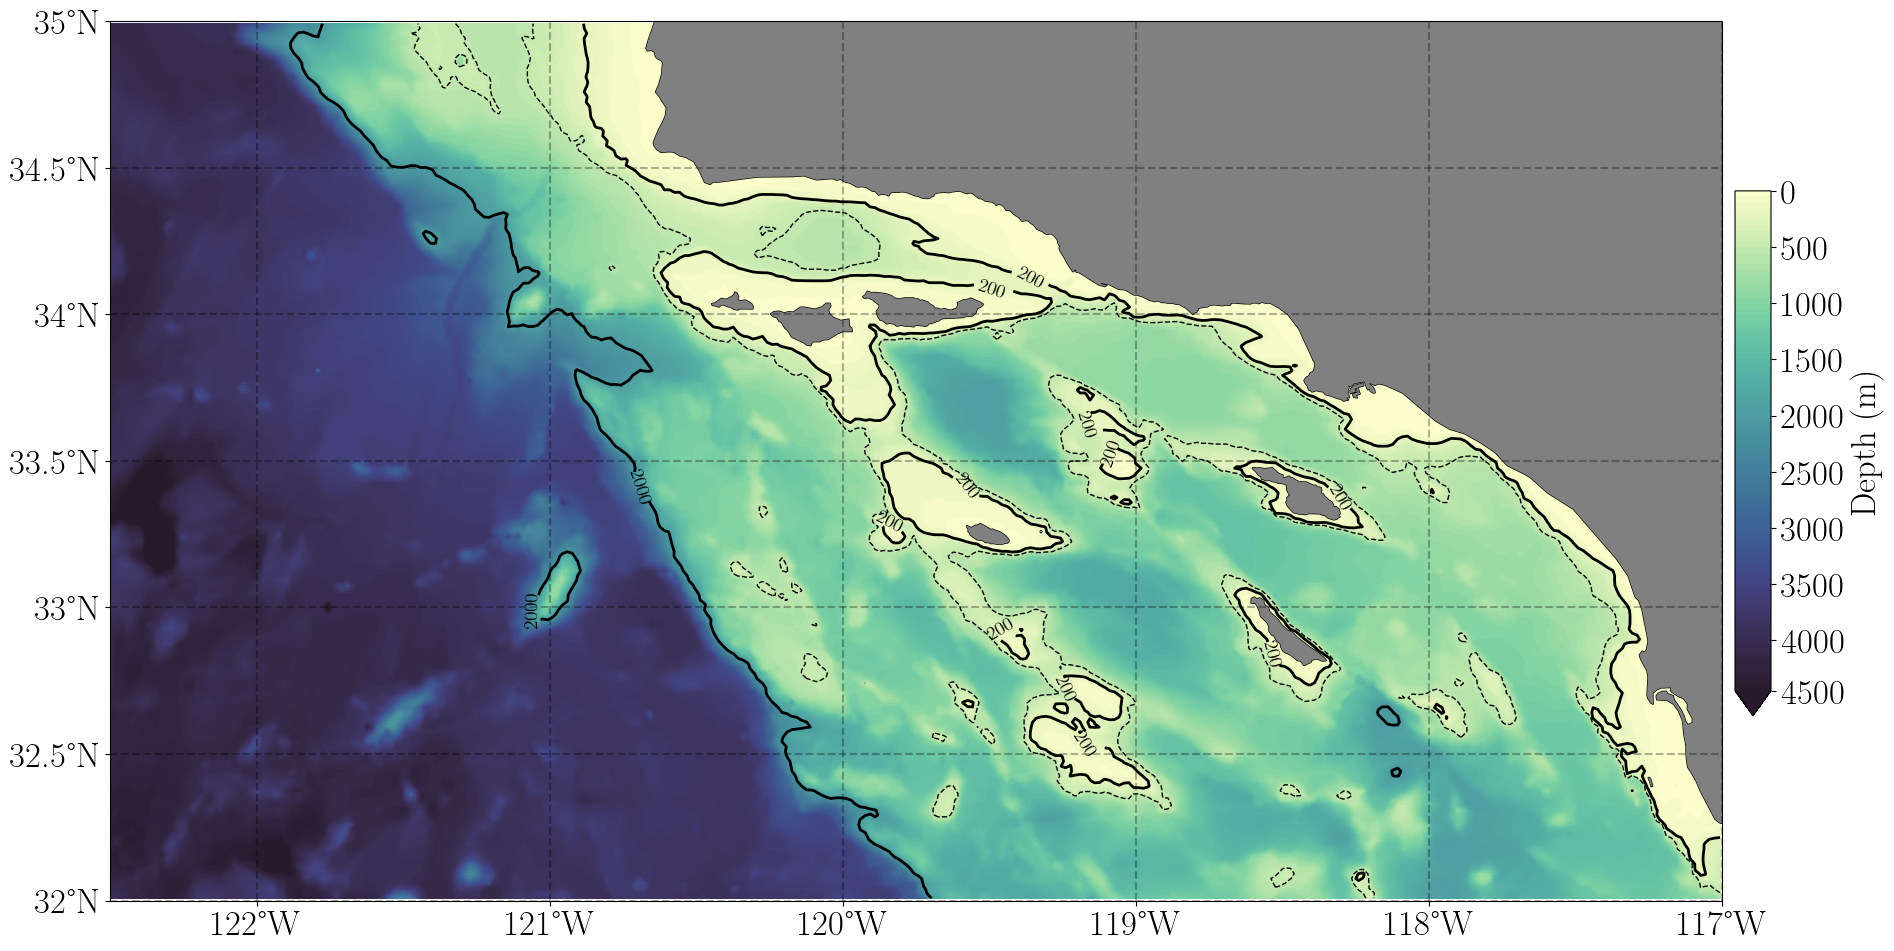

In [48]:
# Set figure font 
fontsize = 14
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
})

# Set plotting parameters
projection = ccrs.PlateCarree(central_longitude=0.0)
xticks = [-122, -121, -120, -119, -118, -117]
yticks = [32.00, 32.50, 33.00, 33.50,  34.00, 34.50,  35.00]
resolution = "10m"
bounds = np.arange(0,360+40,40)
lon_min = -122.5
lon_max = -117
lat_min = 32.5
lat_max = 35
levels = np.arange(0, 4500, 50) 
fontsize_m = 25
fontsize_g = 25

# Create figure
fig, axes = plt.subplots(1,1, figsize=(18, 15), subplot_kw={"projection": projection})

# Set figure axes 
cart.set_subplots(axes, projection, resolution, lon_min=lon_min, lon_max=lon_max, lat_min=lat_min, lat_max=lat_max) 

# Plot bathymetry
mesh = axes.contourf(
    lon_grid_n, lat_grid_n, abs(bathy_grid_n), levels=levels,
    transform=ccrs.PlateCarree(),
    cmap=cmocean.cm.deep,  
    shading="auto", 
    extend = 'max'
)

# Define the same normalization used for the contourf plot
norm = mcolors.Normalize(vmin=levels.min(), vmax=levels.max())

# Plot depth contour lines
level_innershelf = np.arange(0,300,100)
levels_midshelf = np.arange(1000,3000,500)
contour1 = axes.contour(lon_grid_n, lat_grid_n, -1*(bathy_grid_n),levels=[500], colors='black', linewidths=1, linestyles='dashed')
contour2 = axes.contour(lon_grid_n, lat_grid_n, -1*(bathy_grid_n),levels=[2000], colors='black', linewidths=2, linestyles='solid')
#contour3 = axes.contour(lon_grid_n, lat_grid_n, -1*(bathy_grid_n),levels=[80], colors='black', linewidths=1, linestyles='dashed')
contour4 = axes.contour(lon_grid_n, lat_grid_n, -1*(bathy_grid_n),levels=[200], colors='black', linewidths=2, linestyles='solid')
#plt.clabel(contour1, fontsize=fontsize)
plt.clabel(contour2, fontsize=fontsize)
#plt.clabel(contour3, fontsize=fontsize)
plt.clabel(contour4, fontsize=fontsize)

# Set grid ticks 
cart.set_grid_ticks(
    axes,
    projection=ccrs.PlateCarree(),
    xticks=xticks,
    yticks=yticks,
    xlabels=True,
    ylabels=True,
    grid=False,
    fontsize=fontsize_g,
    color="black",
)
axes.grid(linewidth=1.5, color='black', alpha=0.3, linestyle='--')

# Create colormap
cax = plt.axes([0.97, 0.33, 0.02, 0.35])
cart.set_cbar(
    mesh,
    cax,
    fig,
    orientation="vertical",
    extend="both",
    cbar_label=r'Depth (m)',
    nbins=10,
    fontsize=fontsize_g,
    cbar_ticks=[], 
    task="regular",
    option_invert = 1
)

# Display figure
plt.tight_layout()
plt.show()

# Save with high quality
fig.savefig(
    PATH_figs + 'fig20.png',
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)

In [8]:

fontsize=16
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
})

Plot the potential density, along-shelf velocity, and cross-shelf velocity profile time series

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_12267/18120308.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


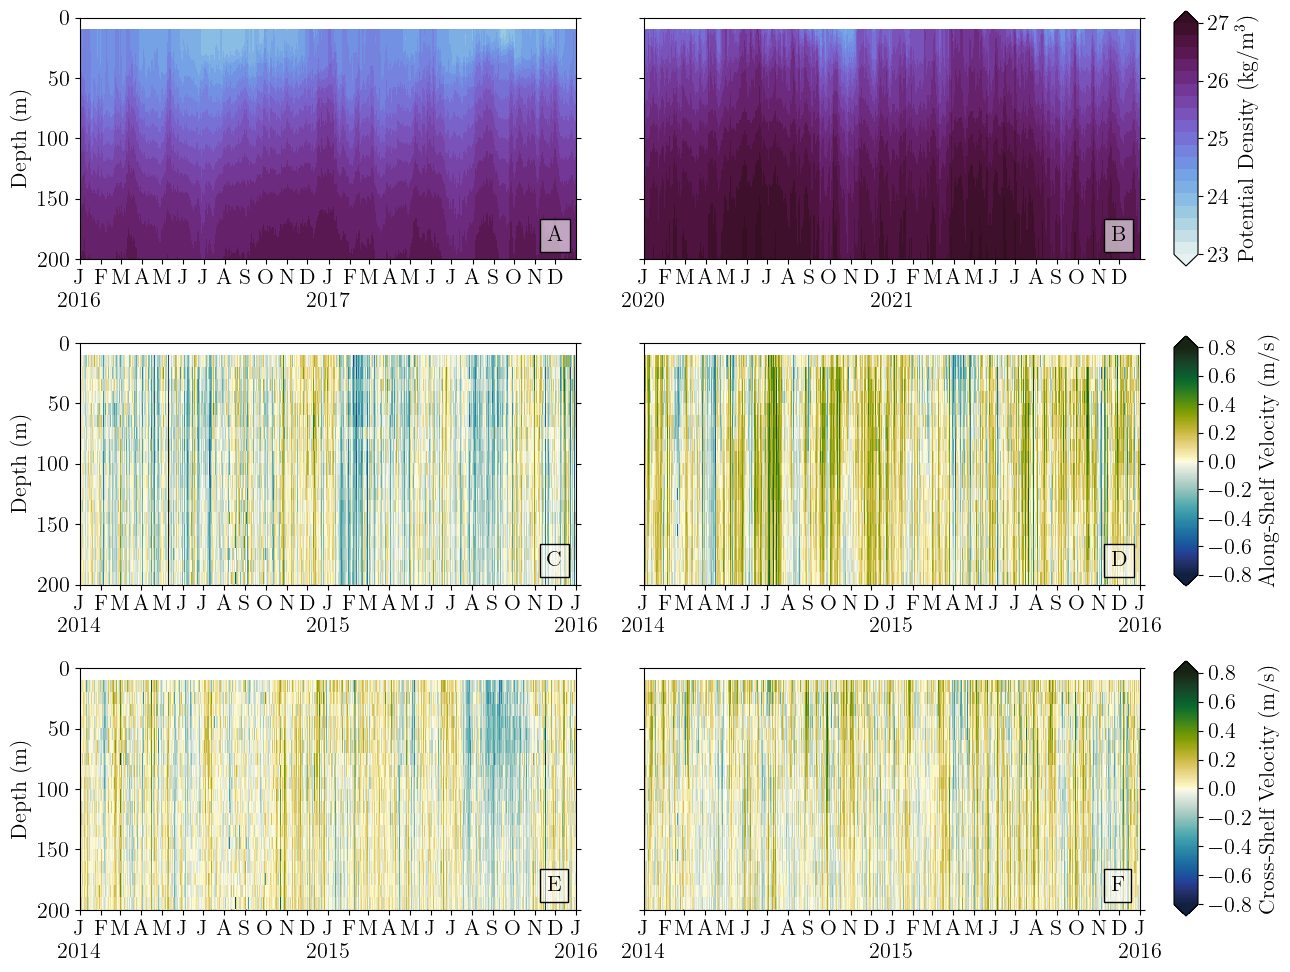

In [14]:
# Set contour levels
vmin_sig,vmax_sig = 23,27
vmin_vel,vmax_vel = -0.8,0.8
level_sig = np.linspace(vmin_sig,vmax_sig,20)
level_vel = np.linspace(vmin_vel,vmax_vel,20)

# Create a normalization object
norm_sig = mcolors.Normalize(vmin=vmin_sig, vmax=vmax_sig)
norm_vel = mcolors.TwoSlopeNorm(vmin=vmin_vel, vcenter=0, vmax=vmax_vel)

# Create figure
fig,axes = plt.subplots(3,2,figsize=(12, 10))
ax1,ax2,ax3,ax4,ax5,ax6 =  axes.flatten()

#--- Subplot 1 ---# 

# Plot CCE1 potential density
cf = ax1.contourf(time1_dt,abs(depth1),RHO1, levels = level_sig, cmap=cmocean.cm.dense,norm=norm_sig, extend='both')

# Set axis attributes
ax1.set_ylabel("Depth (m)")
ax1.set_ylim(0,200)
ax1.invert_yaxis()
ax1.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(FuncFormatter(month_fmt))

#--- Subplot 2 ---# 

# Plot CCE2 potential density
ax2.contourf(time2_dt,abs(depth2),RHO2, levels = level_sig, cmap=cmocean.cm.dense,norm=norm_sig, extend='both')

# Set axis attributes
ax2.set_ylim(0,200)
ax2.invert_yaxis()
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(FuncFormatter(month_fmt))
ax2.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
ax2.set_yticklabels([])

# Set colorbar
cax = fig.add_axes([0.99, 0.72, 0.02, 0.255])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both')
cbar.set_ticks([23, 24, 25, 26, 27]) 
cbar.set_label(r'Potential Density (kg/m$^3$)')

#--- Subplot 3 ---# 

# Plot CCE1 along-shelf velocity
cf = ax3.pcolormesh(time1_adcp_dt,abs(depth1_adcp),U1, cmap=cmocean.cm.delta,vmin=vmin_vel,vmax=vmax_vel)

# Set axis attributes
ax3.set_ylabel("Depth (m)")
ax3.set_ylim(0,200)
ax3.invert_yaxis()
ax3.xaxis.set_major_locator(mdates.MonthLocator())
ax3.xaxis.set_major_formatter(FuncFormatter(month_fmt))
ax3.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)

#--- Subplot 4 ---# 

# Plot CCE2 along-shelf velocity
ax4.pcolormesh(time2_adcp_dt,abs(depth2_adcp),U2, cmap=cmocean.cm.delta,vmin=vmin_vel,vmax=vmax_vel)

# Set axis attributes
ax4.set_ylim(0,200)
ax4.invert_yaxis()
ax4.xaxis.set_major_locator(mdates.MonthLocator())
ax4.xaxis.set_major_formatter(FuncFormatter(month_fmt))
ax4.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
ax4.set_yticklabels([])

# Set colorbar
cax = fig.add_axes([0.99, 0.40, 0.02, 0.25])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both')
cbar.ax.set_ylim(vmin_vel,vmax_vel)
cbar.set_ticks(np.arange(vmin_vel,vmax_vel+0.2,0.2))  
cbar.set_label(r'Along-Shelf Velocity (m/s)')

#--- Subplot 5 ---# 

# Plot CCE1 cross-shelf velocity
cf = ax5.pcolormesh(time1_adcp_dt,abs(depth1_adcp),V1, cmap=cmocean.cm.delta,vmin=vmin_vel,vmax=vmax_vel)

# Set axis attributes
ax5.set_ylabel("Depth (m)")
ax5.set_ylim(0,200)
ax5.invert_yaxis()
ax5.xaxis.set_major_locator(mdates.MonthLocator())
ax5.xaxis.set_major_formatter(FuncFormatter(month_fmt))
ax5.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)

#--- Subplot 6 ---# 

# Plot CCE2 cross-shelf velocity
ax6.pcolormesh(time2_adcp_dt,abs(depth2_adcp),V2, cmap=cmocean.cm.delta,vmin=vmin_vel,vmax=vmax_vel)

# Set axis attributes
ax6.set_ylim(0,200)
ax6.invert_yaxis()
ax6.xaxis.set_major_locator(mdates.MonthLocator())
ax6.xaxis.set_major_formatter(FuncFormatter(month_fmt))
ax6.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
ax6.set_yticklabels([])

# Set colorbar
cax = fig.add_axes([0.99, 0.07, 0.02, 0.255])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both')
cbar.ax.set_ylim(vmin_vel,vmax_vel)
cbar.set_ticks(np.arange(vmin_vel,vmax_vel+0.2,0.2))  
cbar.set_label(r'Cross-Shelf Velocity (m/s)')

# Label each subplot
pos = [0.94, 0.14]
add_corner_label(ax1, pos, 'A', fontsize = fontsize)
add_corner_label(ax2, pos, 'B', fontsize = fontsize)
add_corner_label(ax3, pos, 'C', fontsize = fontsize)
add_corner_label(ax4, pos, 'D', fontsize = fontsize)
add_corner_label(ax5, pos, 'E', fontsize = fontsize)
add_corner_label(ax6, pos, 'F', fontsize = fontsize)

# Show figure
plt.tight_layout()
plt.show()

/var/folders/2q/rg93ky5n09l14670ynhs0cgh0000gn/T/ipykernel_12267/361539791.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


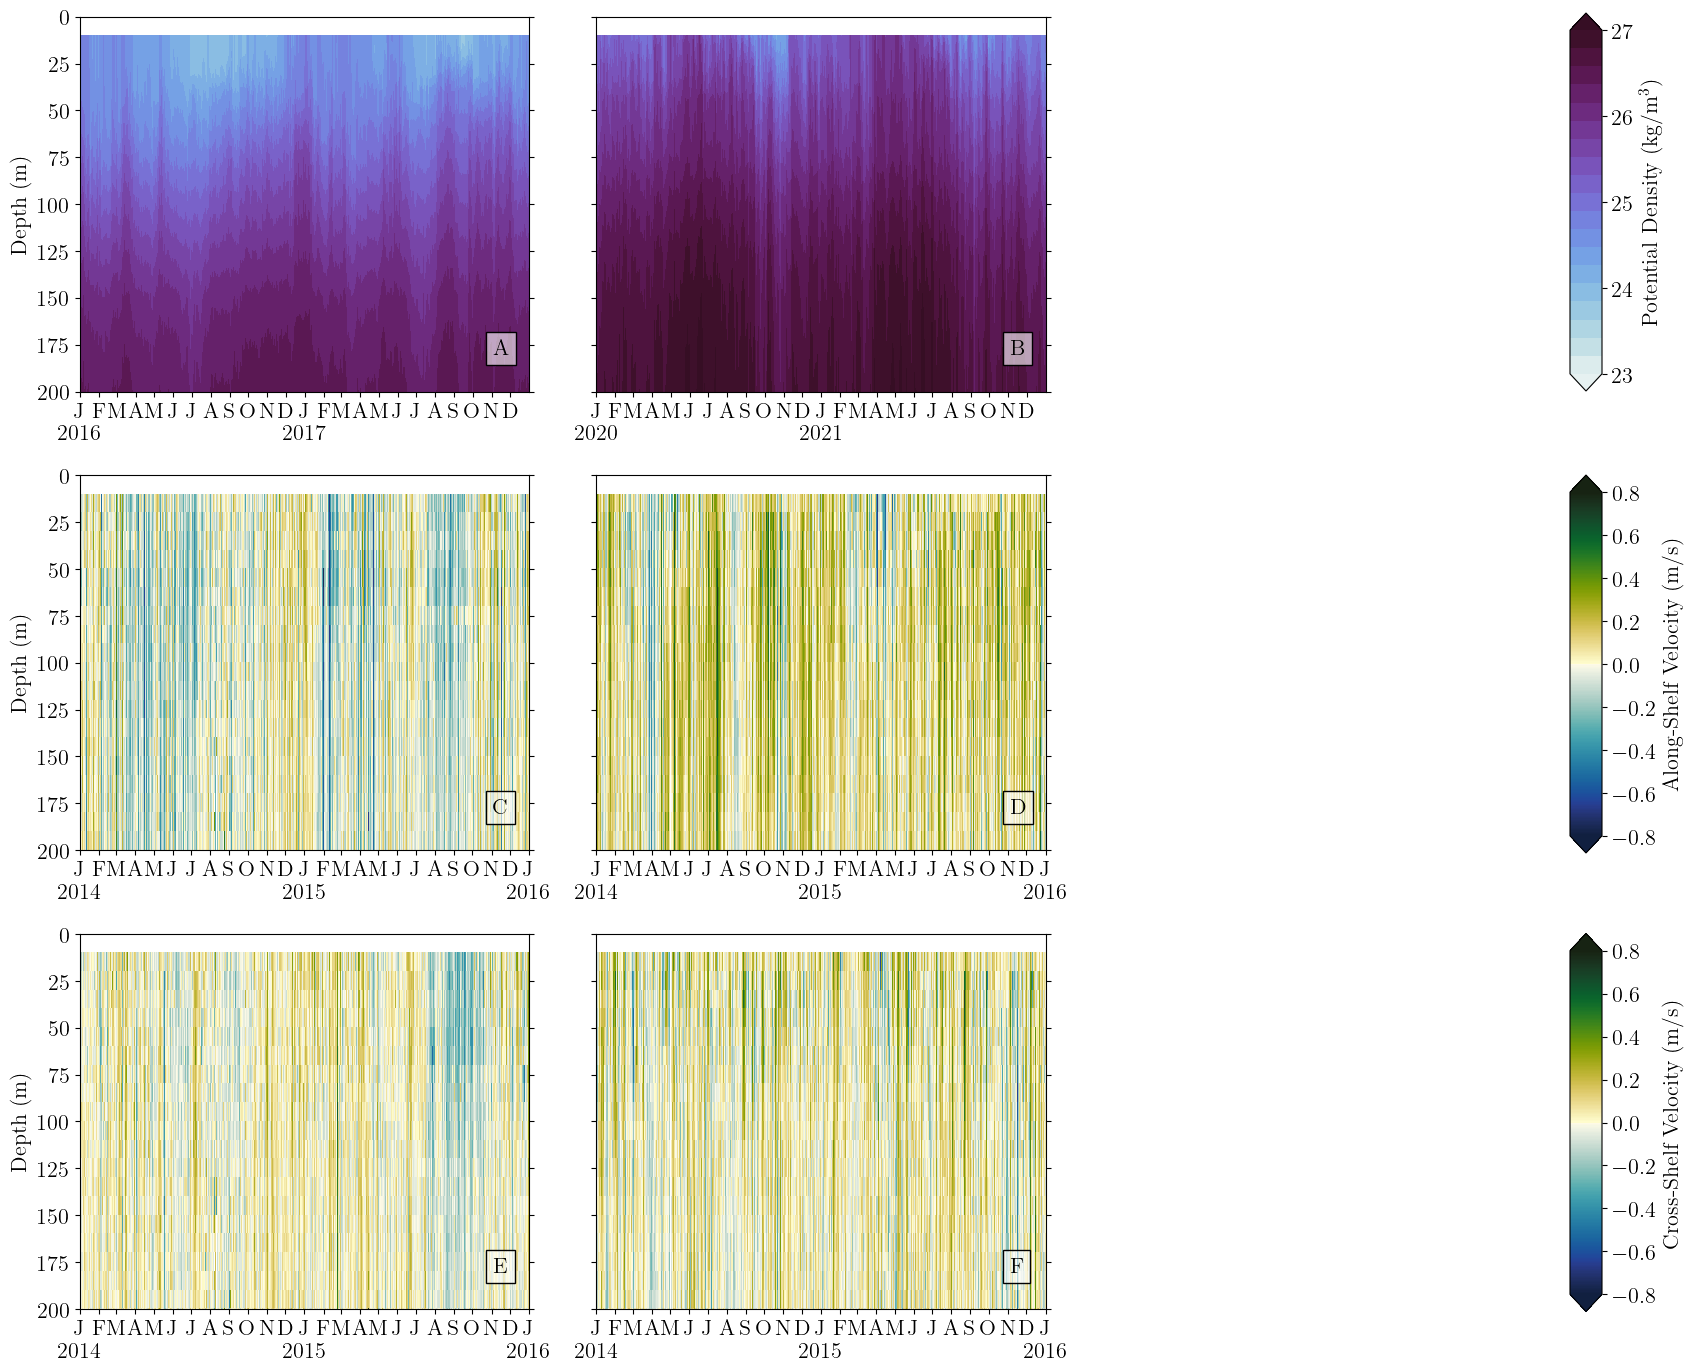

In [34]:
# Set contour levels
vmin_sig,vmax_sig = 23,27
vmin_vel,vmax_vel = -0.8,0.8
level_sig = np.linspace(vmin_sig,vmax_sig,20)
level_vel = np.linspace(vmin_vel,vmax_vel,20)

# Create a normalization object
norm_sig = mcolors.Normalize(vmin=vmin_sig, vmax=vmax_sig)
norm_vel = mcolors.TwoSlopeNorm(vmin=vmin_vel, vcenter=0, vmax=vmax_vel)

# Create figure
fig,axes = plt.subplots(3,3,figsize=(16, 14))
ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8,ax9 = axes.flatten()

#--- Subplot 1 ---# 

# Plot CCE1 potential density
cf = ax1.contourf(time1_dt,abs(depth1),RHO1, levels = level_sig, cmap=cmocean.cm.dense,norm=norm_sig, extend='both')

# Set axis attributes
ax1.set_ylabel("Depth (m)")
ax1.set_ylim(0,200)
ax1.invert_yaxis()
ax1.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(FuncFormatter(month_fmt))

#--- Subplot 2 ---# 

# Plot CCE2 potential density
ax2.contourf(time2_dt,abs(depth2),RHO2, levels = level_sig, cmap=cmocean.cm.dense,norm=norm_sig, extend='both')

# Set axis attributes
ax2.set_ylim(0,200)
ax2.invert_yaxis()
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(FuncFormatter(month_fmt))
ax2.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
ax2.set_yticklabels([])

#--- Subplot 3 ---# 

ax3.axis('off')

# Set colorbar
cax = fig.add_axes([0.99, 0.71, 0.02, 0.27])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both')
cbar.set_ticks([23, 24, 25, 26, 27]) 
cbar.set_label(r'Potential Density (kg/m$^3$)')

#--- Subplot 4 ---# 

# Plot CCE1 along-shelf velocity
cf = ax4.pcolormesh(time1_adcp_dt,abs(depth1_adcp),U1, cmap=cmocean.cm.delta,vmin=vmin_vel,vmax=vmax_vel)

# Set axis attributes
ax4.set_ylabel("Depth (m)")
ax4.set_ylim(0,200)
ax4.invert_yaxis()
ax4.xaxis.set_major_locator(mdates.MonthLocator())
ax4.xaxis.set_major_formatter(FuncFormatter(month_fmt))
ax4.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)

#--- Subplot 5 ---# 

# Plot CCE2 along-shelf velocity
ax5.pcolormesh(time2_adcp_dt,abs(depth2_adcp),U2, cmap=cmocean.cm.delta,vmin=vmin_vel,vmax=vmax_vel)

# Set axis attributes
ax5.set_ylim(0,200)
ax5.invert_yaxis()
ax5.xaxis.set_major_locator(mdates.MonthLocator())
ax5.xaxis.set_major_formatter(FuncFormatter(month_fmt))
ax5.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
ax5.set_yticklabels([])

#--- Subplot 6 ---# 

ax6.axis('off')

# Set colorbar
cax = fig.add_axes([0.99, 0.38, 0.02, 0.27])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both')
cbar.ax.set_ylim(vmin_vel,vmax_vel)
cbar.set_ticks(np.arange(vmin_vel,vmax_vel+0.2,0.2))  
cbar.set_label(r'Along-Shelf Velocity (m/s)')

#--- Subplot 7 ---# 

# Plot CCE1 cross-shelf velocity
cf = ax7.pcolormesh(time1_adcp_dt,abs(depth1_adcp),V1, cmap=cmocean.cm.delta,vmin=vmin_vel,vmax=vmax_vel)

# Set axis attributes
ax7.set_ylabel("Depth (m)")
ax7.set_ylim(0,200)
ax7.invert_yaxis()
ax7.xaxis.set_major_locator(mdates.MonthLocator())
ax7.xaxis.set_major_formatter(FuncFormatter(month_fmt))
ax7.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)

#--- Subplot 8 ---# 

# Plot CCE2 cross-shelf velocity
ax8.pcolormesh(time2_adcp_dt,abs(depth2_adcp),V2, cmap=cmocean.cm.delta,vmin=vmin_vel,vmax=vmax_vel)

# Set axis attributes
ax8.set_ylim(0,200)
ax8.invert_yaxis()
ax8.xaxis.set_major_locator(mdates.MonthLocator())
ax8.xaxis.set_major_formatter(FuncFormatter(month_fmt))
ax8.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
ax8.set_yticklabels([])

#--- Subplot 9 ---# 

ax9.axis('off')

# Set colorbar
cax = fig.add_axes([0.99, 0.0525, 0.02, 0.27])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both')
cbar.ax.set_ylim(vmin_vel,vmax_vel)
cbar.set_ticks(np.arange(vmin_vel,vmax_vel+0.2,0.2))  
cbar.set_label(r'Cross-Shelf Velocity (m/s)')

# Label each subplot
pos = [0.92, 0.14]
add_corner_label(ax1, pos, 'A', fontsize = fontsize)
add_corner_label(ax2, pos, 'B', fontsize = fontsize)
add_corner_label(ax4, pos, 'C', fontsize = fontsize)
add_corner_label(ax5, pos, 'D', fontsize = fontsize)
add_corner_label(ax7, pos, 'E', fontsize = fontsize)
add_corner_label(ax8, pos, 'F', fontsize = fontsize)

# Show figure
plt.tight_layout()
plt.show()

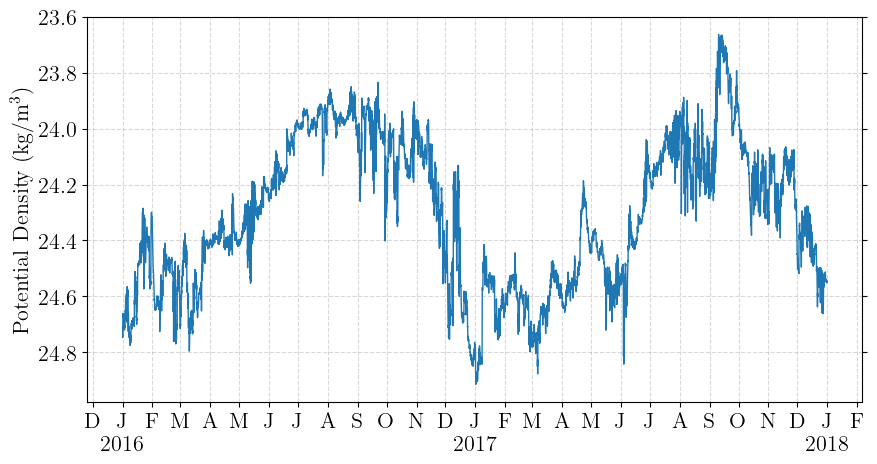

In [28]:
# Extract depth level
rho1_d = RHO1[0,:]

# Create figure
fig,axes = plt.subplots(figsize=(10, 5))

#--- Subplot 1 ---# 

# Plot CCE1 potential density at one depth level
axes.plot(time1_dt,rho1_d, lw=1, ls='-', color='tab:blue')

# Set axis attributes
axes.set_ylabel(r"Potential Density (kg/m$^3$)")
axes.invert_yaxis()
axes.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
axes.xaxis.set_major_locator(mdates.MonthLocator())
axes.xaxis.set_major_formatter(FuncFormatter(month_fmt))
axes.grid(True,ls='--',color='grey',alpha=0.3)

Remove temporal mean and annual/semi-annual cycles 

In [30]:
# Set parameters
w1, w2 = [(2*np.pi)/31557600, (1/2)*(2*np.pi)/31557600]   

# Convert to seconds since start time
t0 = time1[0]
time_elapsed = np.array([(t - t0).total_seconds() for t in time1])

# Remove annual and semi-annual cycle 
hfit, x_data, x_data_sigma, _ = unweighted_lsf(rho1_d, time_elapsed, parameters = 2, freqs = np.array([w1,w2]), sigma = None)
rho1_d_rm = rho1_d - hfit

Plot the time series of potential density anomaly

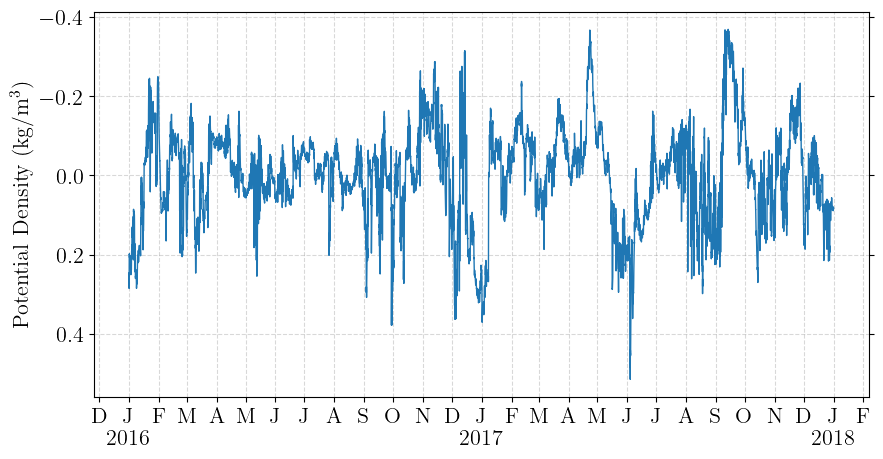

In [31]:
# Create figure
fig,axes = plt.subplots(figsize=(10, 5))

#--- Subplot 1 ---# 

# Plot CCE1 potential density at one depth level
axes.plot(time1_dt,rho1_d_rm, lw=1, ls='-', color='tab:blue')

# Set axis attributes
axes.set_ylabel(r"Potential Density (kg/m$^3$)")
axes.invert_yaxis()
axes.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)
axes.xaxis.set_major_locator(mdates.MonthLocator())
axes.xaxis.set_major_formatter(FuncFormatter(month_fmt))
axes.grid(True,ls='--',color='grey',alpha=0.3)

/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


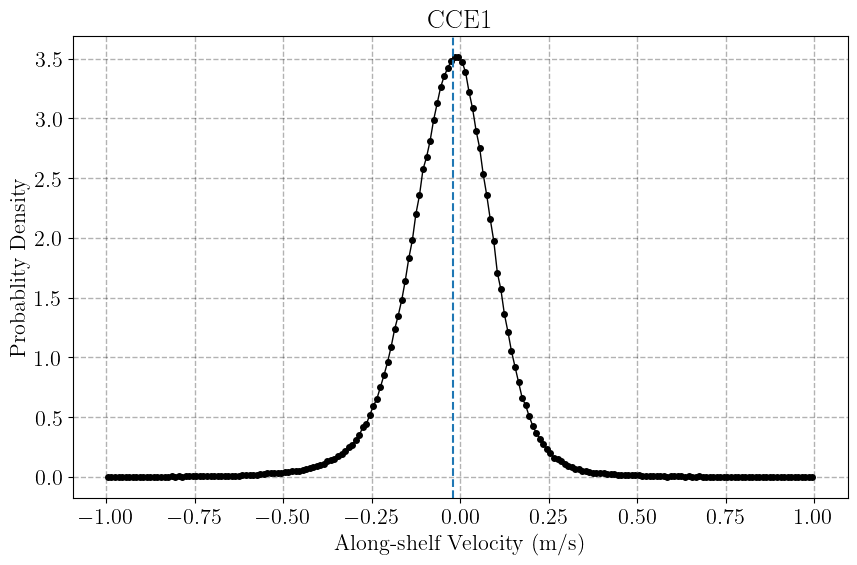

In [9]:
from stats import compute_pdf_1D

# Find depth shallower than 200 meters
idx = depth1_adcp >= 200

# Set parameters for pdf 
edges = np.arange(-1,1+0.01,0.01)

# Compute pdf for along-shelf velocity
counts_U1, pdf_U1, bin_centers = compute_pdf_1D(U1[idx,:],edges)

# Create figure
fig, ax = plt.subplots(figsize=(10,6))

# Plots pdf
ax.plot(bin_centers,pdf_U1,'k.-', linewidth=1,markersize=8)
ax.axvline(np.median(U1[idx,:]),linestyle='--', linewidth=1.5, alpha=1, color='tab:blue')

# Set axis attributes
ax.set_title('CCE1')
ax.set_xlabel('Along-shelf Velocity (m/s)')
ax.set_ylabel('Probablity Density')
ax.grid(True, linestyle='--', linewidth=1, alpha=0.3, color='k')

plt.show()

In [10]:
idx_pos = bin_centers > 0
idx_neg = bin_centers < 0

print(counts_U1[idx_pos].sum())
print(counts_U1[idx_neg].sum())

253011
356993


/Users/lukecolosi/miniforge3/envs/ocean_scales/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


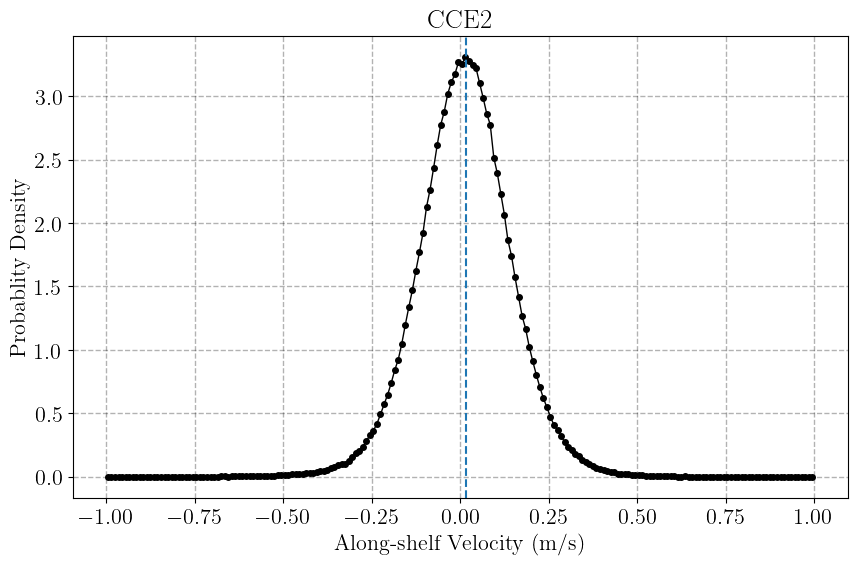

In [11]:
# Find depth shallower than 200 meters
idx = depth2_adcp >= 200

# Set parameters for pdf 
edges = np.arange(-1,1+0.01,0.01)

# Compute pdf for along-shelf velocity
counts, pdf, bin_centers = compute_pdf_1D(U2[idx,:],edges)

# Create figure
fig, ax = plt.subplots(figsize=(10,6))

# Plots pdf
ax.plot(bin_centers,pdf,'k.-', linewidth=1,markersize=8)
ax.axvline(np.median(U2[idx,:]),linestyle='--', linewidth=1.5, alpha=1, color='tab:blue')

# Set axis attributes
ax.set_title('CCE2')
ax.set_xlabel('Along-shelf Velocity (m/s)')
ax.set_ylabel('Probablity Density')
ax.grid(True, linestyle='--', linewidth=1, alpha=0.3, color='k')

plt.show()

NameError: name 'vmax' is not defined

NameError: name 'norm_vel' is not defined

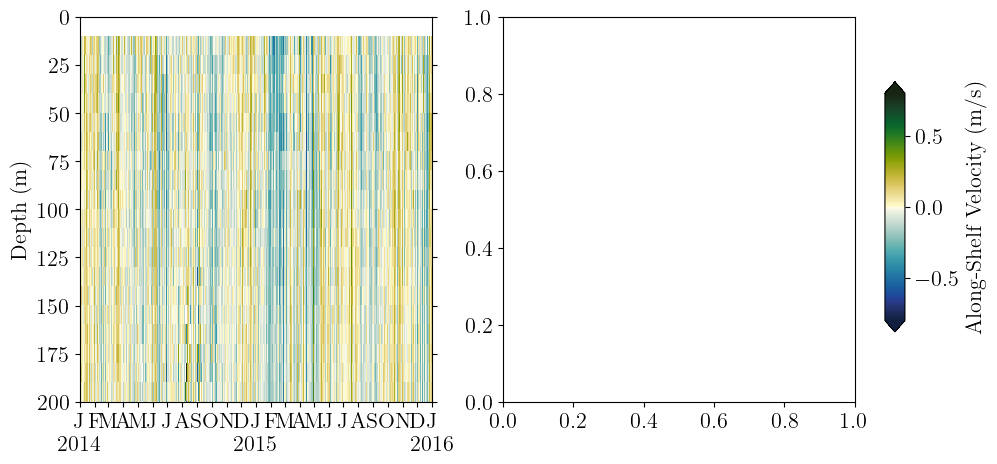

In [13]:
from datetime import timedelta

# Set plotting parameters
level_vel = np.linspace(-0.8,0.8,80)
vmin,vmax = -0.8,0.8

# Create figure 
fig, axes = plt.subplots(1,2,figsize=(10,5))
ax1, ax2 = axes.flatten()

#--- Subplot 1 ---# 

# Plot CCE1 along-shelf velocity
cf = ax1.pcolormesh(time1_adcp_dt,abs(depth1_adcp),U1, cmap=cmocean.cm.delta, vmin=vmin, vmax=vmax)

# Set axis attributes
ax1.set_ylabel("Depth (m)")
ax1.set_ylim(0,200)
ax1.invert_yaxis()
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(FuncFormatter(month_fmt))
ax1.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)

# Set x lims
# t0 = time1_adcp_dt[0]
# ax1.set_xlim(t0,t0+timedelta(days=30))

# Set colorbar
cax = fig.add_axes([0.93, 0.25, 0.02, 0.5])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical', extend='both')
cbar.ax.set_ylim(vmin,vmax)
#cbar.ax.set_yticks(np.arange(vmin,vmax+0.2,0.2))
cbar.set_label(r'Along-Shelf Velocity (m/s)')

#--- Subplot 2 ---# 

# Plot CCE1 along-shelf velocity
cf = ax2.contourf(time1_adcp_dt,abs(depth1_adcp),U1, levels = level_vel, cmap=cmocean.cm.delta, norm=norm_vel)

# Set axis attributes
ax2.set_ylabel("Depth (m)")
ax2.set_ylim(0,200)
ax2.invert_yaxis()
ax2.xaxis.set_major_locator(mdates.MonthLocator())
ax2.xaxis.set_major_formatter(FuncFormatter(month_fmt))
ax2.tick_params(top=False, bottom=True, left=True, right=True,
                direction='out', length=3.5)

# Set x lims
# t0 = time1_adcp_dt[0]
# ax2.set_xlim(t0,t0+timedelta(days=30))

# Set colorbar
cax = fig.add_axes([1.1, 0.25, 0.02, 0.5])# [left, bottom, width, height]
cbar = fig.colorbar(cf, cax=cax, orientation='vertical')
cbar.set_ticks(np.arange(-0.8,0.8+0.2,0.2))  
cbar.set_label(r'Along-Shelf Velocity (m/s)')

# Display figure
plt.show()